In [1]:
pip install networkx

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


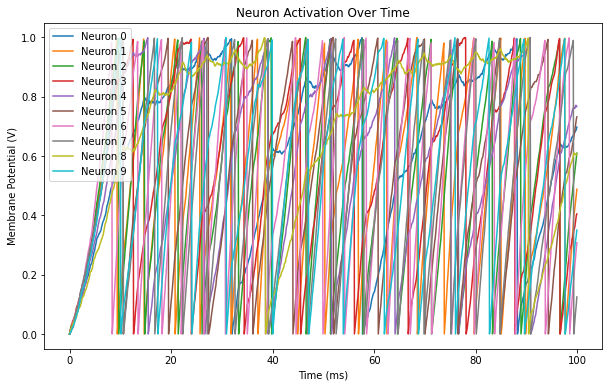

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Create a network
G = nx.erdos_renyi_graph(n=10, p=0.3, directed=True)  # 10 neurons, random connections
weights = {edge: np.random.uniform(0.5, 1.0) for edge in G.edges()}
nx.set_edge_attributes(G, weights, "weight")

# Parameters
V_rest = 0.0  # Resting potential
V_threshold = 1.0  # Threshold
V_reset = 0.0  # Reset potential
tau = 10.0  # Time constant
dt = 0.1  # Time step
time = np.arange(0, 100, dt)
input_current = np.random.uniform(0.0, 1.0, size=(len(G), len(time)))

# Initialize membrane potentials
V = np.zeros((len(G), len(time)))

#stimulate
for t in range(1, len(time)):
    for i, neuron in enumerate(G.nodes):
        input_sum = sum(
            G[neighbor][neuron]["weight"] * V[neighbor, t - 1]
            for neighbor in G.predecessors(neuron)
            if G.has_edge(neighbor, neuron)  # Ensure edge exists
        )
        V[i, t] = V[i, t - 1] + (dt / tau) * (-V[i, t - 1] + input_sum + input_current[i, t])
        if V[i, t] > V_threshold:
            V[i, t] = V_reset  # Firing!




# Plot results
plt.figure(figsize=(10, 6))
for i in range(len(G)):
    plt.plot(time, V[i, :], label=f"Neuron {i}")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (V)")
plt.title("Neuron Activation Over Time")
plt.legend()
plt.show()


In [7]:
print(f"Neuron {neuron}, Neighbor {neighbor}, Edge Exists: {G.has_edge(neighbor, neuron)}")


NameError: name 'neighbor' is not defined

In [8]:
print("Edges in the graph:", list(G.edges(data=True)))


Edges in the graph: [(0, 2, {'weight': 0.6133789262849337}), (0, 7, {'weight': 0.6937011932262669}), (0, 9, {'weight': 0.7396928244871039}), (1, 5, {'weight': 0.692337932992984}), (1, 7, {'weight': 0.5933749131696241}), (1, 9, {'weight': 0.9556977089178802}), (2, 0, {'weight': 0.9790439012075518}), (2, 1, {'weight': 0.6325954026000613}), (2, 3, {'weight': 0.9598794260528688}), (2, 6, {'weight': 0.7678353024573075}), (3, 4, {'weight': 0.8157879219846009}), (3, 5, {'weight': 0.8665349598777015}), (3, 6, {'weight': 0.5153253408159439}), (4, 1, {'weight': 0.8940375196632588}), (4, 2, {'weight': 0.9490507204873413}), (4, 5, {'weight': 0.6747489083105677}), (5, 2, {'weight': 0.541373184364198}), (5, 7, {'weight': 0.5492704338730311}), (5, 9, {'weight': 0.7414526353806778}), (6, 2, {'weight': 0.6777749054126845}), (6, 3, {'weight': 0.9805332339577391}), (7, 1, {'weight': 0.7200940180848752}), (7, 4, {'weight': 0.7364324417003338}), (7, 6, {'weight': 0.6859340313338709}), (7, 8, {'weight': 0.8

Degree Centrality: {0: 0.6666666666666666, 1: 0.6666666666666666, 2: 0.3333333333333333, 3: 0.6666666666666666, 4: 0.4444444444444444, 5: 0.3333333333333333, 6: 0.8888888888888888, 7: 0.5555555555555556, 8: 0.5555555555555556, 9: 0.2222222222222222}
Closeness Centrality: {0: 0.42857142857142855, 1: 0.47368421052631576, 2: 0.391304347826087, 3: 0.5, 4: 0.47368421052631576, 5: 0.45, 6: 0.6428571428571429, 7: 0.5, 8: 0.34615384615384615, 9: 0.45}
Betweenness Centrality: {0: 0.07268518518518519, 1: 0.22361111111111112, 2: 0.12777777777777777, 3: 0.32499999999999996, 4: 0.0625, 5: 0.06944444444444445, 6: 0.36851851851851847, 7: 0.1324074074074074, 8: 0.05555555555555555, 9: 0.0625}
Eigenvector Centrality: {0: 0.291737374421699, 1: 0.44335337264836694, 2: 0.15537590110804425, 3: 0.28646234999503156, 4: 0.28540469942796004, 5: 0.22363562735740783, 6: 0.5726272072790004, 7: 0.2693455784428776, 8: 0.1733798066955037, 9: 0.22393411960951287}
Clustering Coefficient: {0: 0.4642857142857143, 1: 0.3

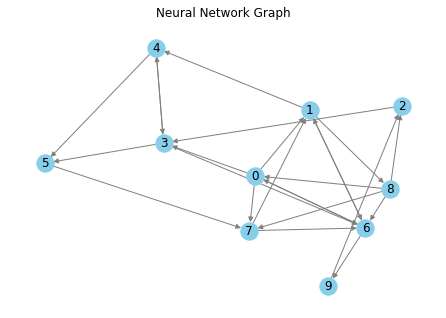

In [9]:
import networkx as nx

# Create a random directed graph (example neural network)
G = nx.erdos_renyi_graph(n=10, p=0.3, directed=True)

# Calculate centrality metrics
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)
clustering_coefficient = nx.clustering(G)

# Print results
print("Degree Centrality:", degree_centrality)
print("Closeness Centrality:", closeness_centrality)
print("Betweenness Centrality:", betweenness_centrality)
print("Eigenvector Centrality:", eigenvector_centrality)
print("Clustering Coefficient:", clustering_coefficient)

# Visualize graph
import matplotlib.pyplot as plt
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray')
plt.title("Neural Network Graph")
plt.show()


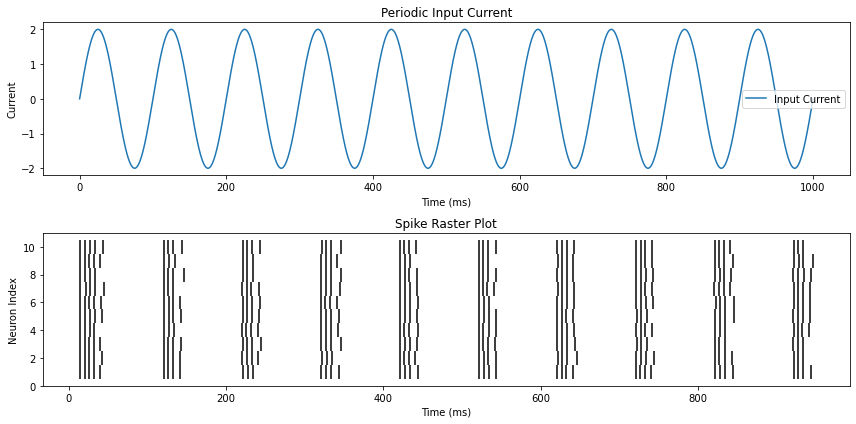

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_neurons = 10  # Number of neurons
tau_m = 20.0  # Membrane time constant (ms)
V_reset = 0.0  # Reset potential
V_threshold = 0.5  # Threshold potential
dt = 0.1  # Time step (ms)
time = np.arange(0, 1000, dt)  # Simulation time (ms)
f = 10.0  # Oscillation frequency (Hz)
I_0 = 2.0  # Input current amplitude
noise_amplitude = 0.5 # Noise amplitude

# Initialize variables
V = np.zeros((n_neurons, len(time)))  # Membrane potentials
spikes = np.zeros((n_neurons, len(time)))  # Spike trains
input_current = I_0 * np.sin(2 * np.pi * f * time / 1000)  # Periodic input current

# Simulate
for t in range(1, len(time)):
    for i in range(n_neurons):
        # Add random noise to input
        noisy_input = input_current[t] + np.random.normal(0, noise_amplitude)
        
        # Update membrane potential
        V[i, t] = V[i, t - 1] + (dt / tau_m) * (-V[i, t - 1] + noisy_input)
        
        # Check for spike
        if V[i, t] > V_threshold:
            V[i, t] = V_reset
            spikes[i, t] = 1  # Record spike

# Plot results
plt.figure(figsize=(12, 6))

# Plot input current
plt.subplot(2, 1, 1)
plt.plot(time, input_current, label="Input Current")
plt.xlabel("Time (ms)")
plt.ylabel("Current")
plt.title("Periodic Input Current")
plt.legend()

# Plot spikes
plt.subplot(2, 1, 2)
for i in range(n_neurons):
    spike_times = time[spikes[i, :] > 0]
    plt.vlines(spike_times, i + 0.5, i + 1.5, color="black")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron Index")
plt.title("Spike Raster Plot")
plt.tight_layout()
plt.show()


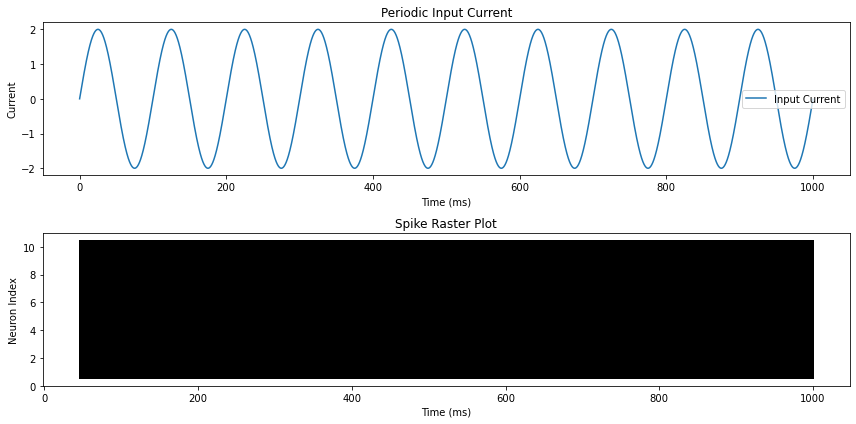

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_neurons = 10  # Number of neurons
tau_m = 20.0  # Membrane time constant (ms)
V_reset = 0.5  # Reset potential
V_threshold = 0.5  # Threshold potential
dt = 0.1  # Time step (ms)
time = np.arange(0, 1000, dt)  # Simulation time (ms)
f = 10.0  # Oscillation frequency (Hz)
I_0 = 2.0  # Input current amplitude
noise_amplitude = 0.5  # Noise amplitude

# Initialize variables
V = np.zeros((n_neurons, len(time)))  # Membrane potentials
spikes = np.zeros((n_neurons, len(time)))  # Spike trains
input_current = I_0 * np.sin(2 * np.pi * f * time / 1000)  # Periodic input current

# Define weights for excitatory and inhibitory connections
W_exc = 0.5  # Excitatory weight
W_inh = -0.3  # Inhibitory weight

# Update rule with feedback
for t in range(1, len(time)):
    for i in range(n_neurons):
        exc_feedback = W_exc * np.sum(spikes[:, t - 1])  # Excitatory feedback
        inh_feedback = W_inh * np.sum(spikes[:, t - 1])  # Inhibitory feedback
        total_feedback = exc_feedback + inh_feedback

        # Update membrane potential
        V[i, t] = V[i, t - 1] + (dt / tau_m) * (-V[i, t - 1] + total_feedback + noisy_input)
        
        # Spike check
        if V[i, t] > V_threshold:
            V[i, t] = V_reset
            spikes[i, t] = 1


# Plot results
plt.figure(figsize=(12, 6))

# Plot input current
plt.subplot(2, 1, 1)
plt.plot(time, input_current, label="Input Current")
plt.xlabel("Time (ms)")
plt.ylabel("Current")
plt.title("Periodic Input Current")
plt.legend()

# Plot spikes
plt.subplot(2, 1, 2)
for i in range(n_neurons):
    spike_times = time[spikes[i, :] > 0]
    plt.vlines(spike_times, i + 0.5, i + 1.5, color="black")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron Index")
plt.title("Spike Raster Plot")
plt.tight_layout()
plt.show()



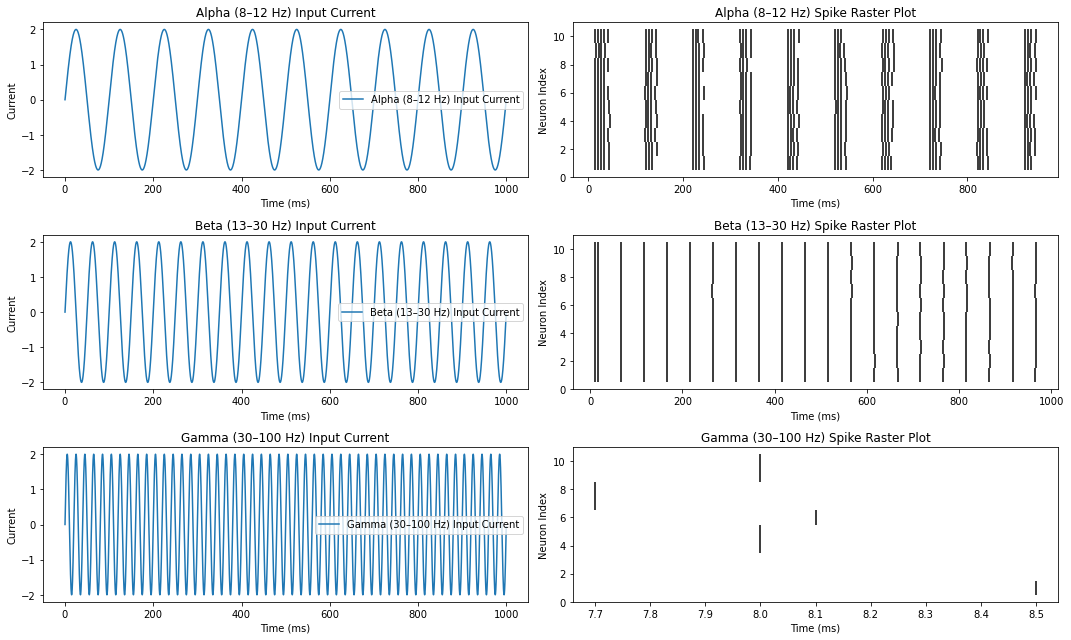

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_neurons = 10  # Number of neurons
tau_m = 20.0  # Membrane time constant (ms)
V_reset = 0.0  # Reset potential
V_threshold = 0.5  # Threshold potential
dt = 0.1  # Time step (ms)
time = np.arange(0, 1000, dt)  # Simulation time (ms)
noise_amplitude = 0.5  # Noise amplitude
I_0 = 2.0  # Input current amplitude

# Frequency bands for oscillations
oscillation_bands = {
    "Alpha (8–12 Hz)": 10,
    "Beta (13–30 Hz)": 20,
    "Gamma (30–100 Hz)": 50,
}

# Initialize figure
plt.figure(figsize=(15, len(oscillation_bands) * 3))

# Simulate for each oscillation band
for idx, (band, f) in enumerate(oscillation_bands.items()):
    # Periodic input current
    input_current = I_0 * np.sin(2 * np.pi * f * time / 1000)
    
    # Initialize variables
    V = np.zeros((n_neurons, len(time)))  # Membrane potentials
    spikes = np.zeros((n_neurons, len(time)))  # Spike trains

    # Simulate
    for t in range(1, len(time)):
        for i in range(n_neurons):
            # Add random noise to input
            noisy_input = input_current[t] + np.random.normal(0, noise_amplitude)
            
            # Update membrane potential
            V[i, t] = V[i, t - 1] + (dt / tau_m) * (-V[i, t - 1] + noisy_input)
            
            # Check for spike
            if V[i, t] > V_threshold:
                V[i, t] = V_reset
                spikes[i, t] = 1  # Record spike

    # Plot input current
    plt.subplot(len(oscillation_bands), 2, 2 * idx + 1)
    plt.plot(time, input_current, label=f"{band} Input Current")
    plt.xlabel("Time (ms)")
    plt.ylabel("Current")
    plt.title(f"{band} Input Current")
    plt.legend()

    # Plot spikes
    plt.subplot(len(oscillation_bands), 2, 2 * idx + 2)
    for i in range(n_neurons):
        spike_times = time[spikes[i, :] > 0]
        plt.vlines(spike_times, i + 0.5, i + 1.5, color="black")
    plt.xlabel("Time (ms)")
    plt.ylabel("Neuron Index")
    plt.title(f"{band} Spike Raster Plot")

plt.tight_layout()
plt.show()


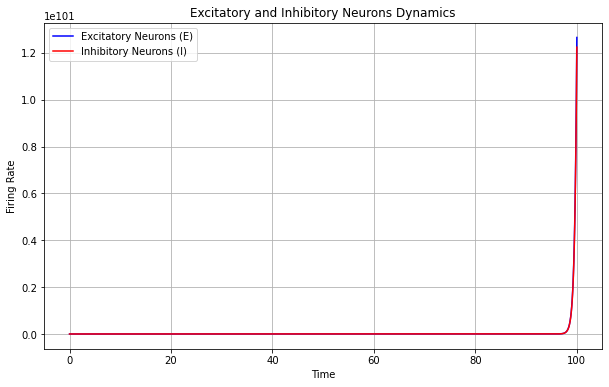

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
alpha_E = 0.1  # decay rate of excitatory neurons
alpha_I = 0.2  # decay rate of inhibitory neurons
beta_E = 0.5   # strength of excitatory influence on inhibitory neurons
beta_I = 0.5   # strength of inhibitory influence on excitatory neurons
J_EE = 1.0     # synaptic coupling between excitatory neurons
J_EI = 1.0     # synaptic coupling between excitatory and inhibitory neurons
J_IE = 1.0     # synaptic coupling between inhibitory and excitatory neurons
J_II = 1.0     # synaptic coupling between inhibitory neurons

# Define the system of ODEs
def model(y, t):
    E, I = y  # E: excitatory neurons, I: inhibitory neurons
    
    dE_dt = -alpha_E * E + beta_E * I + J_EE * E + J_EI * I
    dI_dt = -alpha_I * I + beta_I * E + J_IE * E + J_II * I
    
    return [dE_dt, dI_dt]

# Initial conditions: both populations start at 0
E0 = 0.1
I0 = 0.1
initial_conditions = [E0, I0]

# Time points
t = np.linspace(0, 100, 1000)  # Time range from 0 to 100 with 1000 points

# Solve the ODEs
solution = odeint(model, initial_conditions, t)

# Extract the solutions for E and I
E_solution = solution[:, 0]
I_solution = solution[:, 1]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t, E_solution, label="Excitatory Neurons (E)", color='b')
plt.plot(t, I_solution, label="Inhibitory Neurons (I)", color='r')
plt.xlabel('Time')
plt.ylabel('Firing Rate')
plt.title('Excitatory and Inhibitory Neurons Dynamics')
plt.legend()
plt.grid(True)
plt.show()


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Load connectome data (adjacency matrix) - example format
# Assuming 'connectome.npy' contains an NxN adjacency matrix, where N is the number of regions
connectome = np.load('connectome.npy')

# Parameters for the model
alpha_E = 0.1  # decay rate of excitatory neurons
alpha_I = 0.2  # decay rate of inhibitory neurons
beta_E = 0.5   # strength of excitatory influence on inhibitory neurons
beta_I = 0.5   # strength of inhibitory influence on excitatory neurons

# Define the system of ODEs incorporating the connectome data
def model(y, t, connectome):
    E, I = y  # E: excitatory neurons, I: inhibitory neurons
    N = len(E)  # Number of regions (nodes)

    # Initialize rate of change for each population
    dE_dt = np.zeros(N)
    dI_dt = np.zeros(N)

    for i in range(N):
        # Excitatory to Inhibitory feedback
        dE_dt[i] = -alpha_E * E[i] + beta_E * I[i] + np.dot(connectome[i, :], E) + np.dot(connectome[i, :], I)
        
        # Inhibitory to Excitatory feedback
        dI_dt[i] = -alpha_I * I[i] + beta_I * E[i] + np.dot(connectome[:, i], E) + np.dot(connectome[:, i], I)

    return np.concatenate((dE_dt, dI_dt))

# Initial conditions: both populations start at small activity
N = connectome.shape[0]  # Number of regions (nodes)
E0 = np.random.rand(N) * 0.1  # Random initial excitatory activity
I0 = np.random.rand(N) * 0.1  # Random initial inhibitory activity
initial_conditions = np.concatenate((E0, I0))

# Time points for the simulation
t = np.linspace(0, 100, 1000)

# Solve the ODE system with the connectome data
solution = odeint(model, initial_conditions, t, args=(connectome,))

# Extract the results for E and I
E_solution = solution[:, :N]  # Excitatory neurons (first N elements)
I_solution = solution[:, N:]  # Inhibitory neurons (last N elements)

# Plot the results for the first few regions
plt.figure(figsize=(10, 6))
for i in range(5):  # Plotting first 5 regions for illustration
    plt.plot(t, E_solution[:, i], label=f'Excitatory Region {i+1}', linestyle='-', color='b')
    plt.plot(t, I_solution[:, i], label=f'Inhibitory Region {i+1}', linestyle='--', color='r')

plt.xlabel('Time')
plt.ylabel('Firing Rate')
plt.title('Excitatory and Inhibitory Neurons Dynamics with Connectome Data')
plt.legend()
plt.grid(True)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'connectome.npy'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Load connectome data (adjacency matrix) - example format
connectome = np.load('connectome.npy')

# Parameters for the model
alpha_E = 0.1  # decay rate of excitatory neurons
alpha_I = 0.2  # decay rate of inhibitory neurons
beta_E = 0.5   # strength of excitatory influence on inhibitory neurons
beta_I = 0.5   # strength of inhibitory influence on excitatory neurons
eta = 0.01     # learning rate for Hebbian learning

# Hebbian learning rule for weight update
def hebbian_learning(E_activity, I_activity, weights):
    """
    Update synaptic weights using Hebbian learning rule:
    Δw_ij = η * x_i * x_j
    """
    dW = eta * (np.outer(E_activity, E_activity) + np.outer(I_activity, I_activity))  # Hebbian update rule
    weights += dW  # Update synaptic weights
    return weights

# Define the system of ODEs incorporating the connectome data and Hebbian learning
def model(y, t, connectome, weights):
    E, I = y  # E: excitatory neurons, I: inhibitory neurons
    N = len(E)  # Number of regions (nodes)

    # Initialize rate of change for each population
    dE_dt = np.zeros(N)
    dI_dt = np.zeros(N)

    # Update synaptic weights using Hebbian learning rule
    weights = hebbian_learning(E, I, weights)

    for i in range(N):
        # Excitatory to Inhibitory feedback
        dE_dt[i] = -alpha_E * E[i] + beta_E * I[i] + np.dot(weights[i, :], E) + np.dot(weights[i, :], I)
        
        # Inhibitory to Excitatory feedback
        dI_dt[i] = -alpha_I * I[i] + beta_I * E[i] + np.dot(weights[:, i], E) + np.dot(weights[:, i], I)

    return np.concatenate((dE_dt, dI_dt)), weights

# Initial conditions: both populations start at small activity
N = connectome.shape[0]  # Number of regions (nodes)
E0 = np.random.rand(N) * 0.1  # Random initial excitatory activity
I0 = np.random.rand(N) * 0.1  # Random initial inhibitory activity
initial_conditions = np.concatenate((E0, I0))

# Initial synaptic weights (can be based on the connectome)
weights = np.random.rand(N, N) * 0.1  # Initialize weights randomly

# Time points for the simulation
t = np.linspace(0, 100, 1000)

# Solve the ODE system with Hebbian learning
solution = odeint(model, initial_conditions, t, args=(connectome, weights))

# Extract the results for E and I
E_solution = solution[:, :N]  # Excitatory neurons (first N elements)
I_solution = solution[:, N:]  # Inhibitory neurons (last N elements)

# Plot the results for the first few regions
plt.figure(figsize=(10, 6))
for i in range(5):  # Plotting first 5 regions for illustration
    plt.plot(t, E_solution[:, i], label=f'Excitatory Region {i+1}', linestyle='-', color='b')
    plt.plot(t, I_solution[:, i], label=f'Inhibitory Region {i+1}', linestyle='--', color='r')

plt.xlabel('Time')
plt.ylabel('Firing Rate')
plt.title('Excitatory and Inhibitory Neurons Dynamics with Hebbian Learning')
plt.legend()
plt.grid(True)
plt.show()


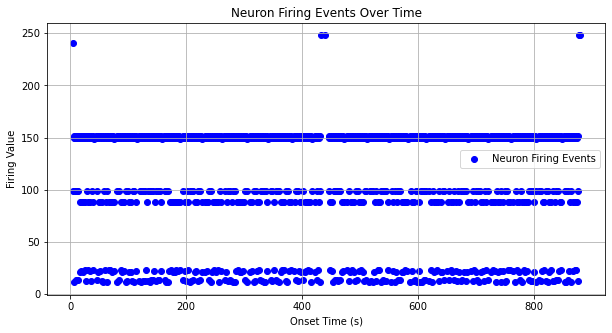

             onset  duration         sample        value
count  1111.000000       0.0    1111.000000  1111.000000
mean    441.849735       NaN  220924.867687   104.391539
std     255.049706       NaN  127524.853171    55.370421
min       4.518000       NaN    2259.000000    11.000000
25%     218.397000       NaN  109198.500000    88.000000
50%     448.172000       NaN  224086.000000   149.000000
75%     664.388000       NaN  332194.000000   150.000000
max     879.894000       NaN  439947.000000   248.000000


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# File path
file_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/sub-1/eeg/sub-1_task-flankersFAR_events.tsv"

# Load data
df = pd.read_csv(file_path, sep="\t")

# Convert 'onset' to numeric and filter NaN values
df['onset'] = pd.to_numeric(df['onset'], errors='coerce')
df.dropna(subset=['onset'], inplace=True)

# Plot neuron firing events over time
plt.figure(figsize=(10, 5))
plt.scatter(df['onset'], df['value'], color='blue', label='Neuron Firing Events')
plt.xlabel('Onset Time (s)')
plt.ylabel('Firing Value')
plt.title('Neuron Firing Events Over Time')
plt.grid(True)
plt.legend()
plt.show()

# Print basic statistics
print(df.describe())


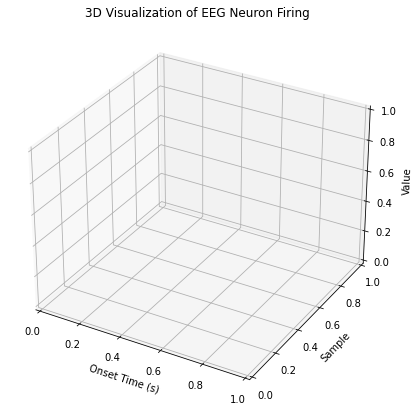

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D

# Load EEG event data
file_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/sub-1/eeg/sub-1_task-flankersFAR_events.tsv"
df = pd.read_csv(file_path, sep="\t")

# Convert necessary columns to numeric
df['onset'] = pd.to_numeric(df['onset'], errors='coerce')
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df.dropna(inplace=True)

# Create a 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Normalize data
x = df['onset'].values
y = df['sample'].values
z = df['value'].values

# Create a network graph structure
G = nx.Graph()
for i in range(len(df) - 1):
    G.add_edge(i, i + 1, weight=abs(z[i + 1] - z[i]))

# Layout for visualization
pos = {i: (x[i], y[i], z[i]) for i in range(len(df))}
colors = plt.cm.jet(np.linspace(0, 1, len(df)))

# Plot nodes
for i in range(len(df)):
    ax.scatter(x[i], y[i], z[i], c=[colors[i]], s=20)

# Plot edges with lines
for edge in G.edges():
    x_line = [pos[edge[0]][0], pos[edge[1]][0]]
    y_line = [pos[edge[0]][1], pos[edge[1]][1]]
    z_line = [pos[edge[0]][2], pos[edge[1]][2]]
    ax.plot(x_line, y_line, z_line, color='green', alpha=0.5)

# Customize plot appearance
ax.set_xlabel('Onset Time (s)')
ax.set_ylabel('Sample')
ax.set_zlabel('Value')
ax.set_title('3D Visualization of EEG Neuron Firing')
plt.show()


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D

# Load EEG event data
file_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/sub-1/eeg/sub-1_task-flankersFAR_events.tsv"
df = pd.read_csv(file_path, sep="\t")

# Convert necessary columns to numeric, handling missing values
df['onset'] = pd.to_numeric(df['onset'], errors='coerce')
df['sample'] = pd.to_numeric(df['sample'], errors='coerce')
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df.dropna(inplace=True)  # Remove rows with NaN values

# Prepare 3D plot data
x = df['onset'].values
y = df['sample'].values
z = df['value'].values

# Normalize data for better visualization
x = (x - np.min(x)) / (np.max(x) - np.min(x))
y = (y - np.min(y)) / (np.max(y) - np.min(y))
z = (z - np.min(z)) / (np.max(z) - np.min(z))

# Create 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Create a graph and add edges
G = nx.Graph()
for i in range(len(df) - 1):
    G.add_edge(i, i + 1)

# Define color mapping for visualization
colors = plt.cm.plasma(np.linspace(0, 1, len(df)))

# Plot nodes
ax.scatter(x, y, z, c=colors, s=30)

# Plot edges
for edge in G.edges():
    x_line = [x[edge[0]], x[edge[1]]]
    y_line = [y[edge[0]], y[edge[1]]]
    z_line = [z[edge[0]], z[edge[1]]]
    ax.plot(x_line, y_line, z_line, color='cyan', linewidth=0.5, alpha=0.7)

# Set labels and title
ax.set_xlabel('Onset (normalized)')
ax.set_ylabel('Sample (normalized)')
ax.set_zlabel('Value (normalized)')
ax.set_title('3D EEG Neuron Firing Visualization')

# Show the plot
plt.show()


ValueError: zero-size array to reduction operation minimum which has no identity

In [4]:
print(df.head())  # Check the first few rows
print(df.info())  # Check for missing or non-numeric values


Empty DataFrame
Columns: [onset, duration, sample, value]
Index: []
<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   onset     0 non-null      float64
 1   duration  0 non-null      float64
 2   sample    0 non-null      int64  
 3   value     0 non-null      int64  
dtypes: float64(2), int64(2)
memory usage: 0.0 bytes
None


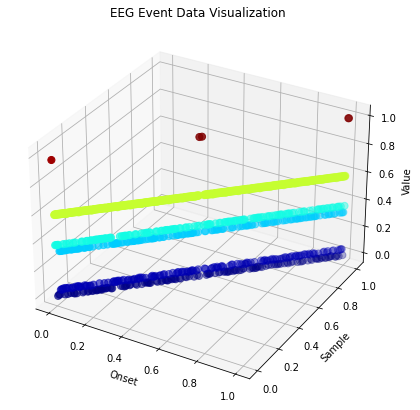

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/sub-1/eeg/sub-1_task-flankersFAR_events.tsv"
df = pd.read_csv(file_path, sep="\t")

# Check and clean data
df = df.dropna(subset=['onset', 'sample', 'value'])
df['onset'] = pd.to_numeric(df['onset'], errors='coerce')
df['sample'] = pd.to_numeric(df['sample'], errors='coerce')
df['value'] = pd.to_numeric(df['value'], errors='coerce')

if df.empty:
    print("No data to visualize.")
else:
    # Prepare data for 3D plotting
    x, y, z = df['onset'].values, df['sample'].values, df['value'].values

    # Normalize data safely
    x = (x - np.min(x)) / (np.max(x) - np.min(x)) if len(x) > 1 else x
    y = (y - np.min(y)) / (np.max(y) - np.min(y)) if len(y) > 1 else y
    z = (z - np.min(z)) / (np.max(z) - np.min(z)) if len(z) > 1 else z

    # Create 3D plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c=z, cmap='jet', s=50)
    
    ax.set_xlabel('Onset')
    ax.set_ylabel('Sample')
    ax.set_zlabel('Value')
    ax.set_title('EEG Event Data Visualization')

    plt.show()


In [1]:
import networkx as nx
import numpy as np
import plotly.graph_objects as go

# Step 1: Generate a random neuron network (graph)
num_neurons = 100  # Adjust as needed
G = nx.random_geometric_graph(num_neurons, radius=0.2)  # Creates spatial connections

# Step 2: Assign random 3D positions
pos = {i: (np.random.rand(), np.random.rand(), np.random.rand()) for i in G.nodes}

# Step 3: Simulate neuron firing (propagation from one node)
active_neurons = set()
start_neuron = np.random.choice(list(G.nodes))
active_neurons.add(start_neuron)

# Step 4: Visualization using Plotly
edges = [(i, j) for i, j in G.edges()]
edge_x, edge_y, edge_z = [], [], []
for edge in edges:
    x0, y0, z0 = pos[edge[0]]
    x1, y1, z1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])
    edge_z.extend([z0, z1, None])

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode='lines', line=dict(color='white', width=1),
    opacity=0.5
)

node_x, node_y, node_z, colors = [], [], [], []
for node in G.nodes():
    x, y, z = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_z.append(z)
    colors.append('red' if node in active_neurons else 'blue')

node_trace = go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title="3D Neural Network Simulation",
    margin=dict(l=0, r=0, b=0, t=40),
    paper_bgcolor="black",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    )
)
fig.show()


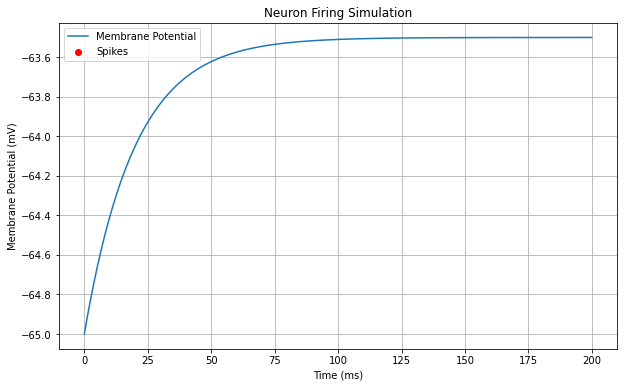

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
tau_m = 20  # Membrane time constant (ms)
V_rest = -65  # Resting potential (mV)
R_m = 1  # Membrane resistance (MΩ)
V_thresh = -50  # Threshold potential (mV)
V_reset = -70  # Reset potential (mV)
dt = 0.1  # Time step (ms)
T = 200  # Total time (ms)
I = 1.5  # Input current (nA)

# Initialize
t = np.arange(0, T, dt)
V = np.full_like(t, V_rest)
spikes = []

# Simulation
for i in range(1, len(t)):
    dV = (-(V[i-1] - V_rest) + R_m * I) * (dt / tau_m)
    V[i] = V[i-1] + dV
    if V[i] >= V_thresh:
        V[i] = V_reset
        spikes.append(t[i])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t, V, label='Membrane Potential')
plt.scatter(spikes, [V_thresh] * len(spikes), color='red', label='Spikes')
plt.title('Neuron Firing Simulation')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
import pandas as pd

file_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/sub-1/eeg/sub-1_task-flankersFAR_events.tsv"
df = pd.read_csv(file_path, sep="\t")
print(df.head())


   onset  duration  sample  value
0  4.518       NaN    2259    241
1  5.068       NaN    2534     99
2  6.074       NaN    3037    150
3  7.096       NaN    3548    151
4  7.616       NaN    3808     11


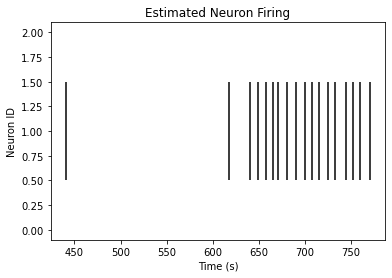

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# Load EEG event data
file_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/sub-1/eeg/sub-1_task-flankersFAR_events.tsv"
df = pd.read_csv(file_path, sep="\t")

# Bandpass filter function
def bandpass_filter(data, lowcut=1, highcut=100, fs=1000, order=4):
    nyq = 0.5 * fs  # Nyquist frequency (500 Hz for fs=1000 Hz)
    low = lowcut / nyq
    high = highcut / nyq
    
    if high >= 1:  # Ensure highcut is below Nyquist
        raise ValueError(f"highcut={highcut} Hz must be < Nyquist frequency ({nyq} Hz)")
    
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Apply bandpass filter to 'value' column
filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)

# Determine dynamic threshold for peak detection
threshold = np.mean(filtered_signal) + np.std(filtered_signal)

# Detect peaks (neuron firing events)
peaks, _ = find_peaks(filtered_signal, height=threshold)
spike_times = df['onset'].iloc[peaks]

# Plot estimated neuron firing times
plt.eventplot(spike_times, colors='black')
plt.xlabel("Time (s)")
plt.ylabel("Neuron ID")
plt.title("Estimated Neuron Firing")
plt.show()


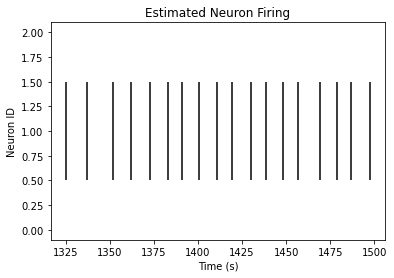

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# Load EEG event data
file_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/sub-2/eeg/sub-2_task-flankersFAR_events.tsv"
df = pd.read_csv(file_path, sep="\t")

# Bandpass filter function
def bandpass_filter(data, lowcut=1, highcut=100, fs=1000, order=4):
    nyq = 0.5 * fs  # Nyquist frequency (500 Hz for fs=1000 Hz)
    low = lowcut / nyq
    high = highcut / nyq
    
    if high >= 1:  # Ensure highcut is below Nyquist
        raise ValueError(f"highcut={highcut} Hz must be < Nyquist frequency ({nyq} Hz)")
    
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Apply bandpass filter to 'value' column
filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)

# Determine dynamic threshold for peak detection
threshold = np.mean(filtered_signal) + np.std(filtered_signal)

# Detect peaks (neuron firing events)
peaks, _ = find_peaks(filtered_signal, height=threshold)
spike_times = df['onset'].iloc[peaks]

# Plot estimated neuron firing times
plt.eventplot(spike_times, colors='black')
plt.xlabel("Time (s)")
plt.ylabel("Neuron ID")
plt.title("Estimated Neuron Firing")
plt.show()


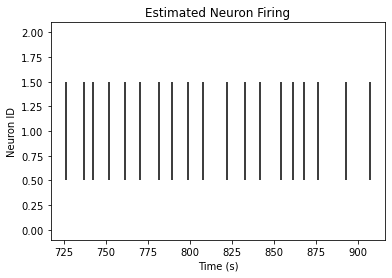

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# Load EEG event data
file_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/sub-3/eeg/sub-3_task-flankersFAR_events.tsv"
df = pd.read_csv(file_path, sep="\t")

# Bandpass filter function
def bandpass_filter(data, lowcut=1, highcut=100, fs=1000, order=4):
    nyq = 0.5 * fs  # Nyquist frequency (500 Hz for fs=1000 Hz)
    low = lowcut / nyq
    high = highcut / nyq
    
    if high >= 1:  # Ensure highcut is below Nyquist
        raise ValueError(f"highcut={highcut} Hz must be < Nyquist frequency ({nyq} Hz)")
    
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Apply bandpass filter to 'value' column
filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)

# Determine dynamic threshold for peak detection
threshold = np.mean(filtered_signal) + np.std(filtered_signal)

# Detect peaks (neuron firing events)
peaks, _ = find_peaks(filtered_signal, height=threshold)
spike_times = df['onset'].iloc[peaks]

# Plot estimated neuron firing times
plt.eventplot(spike_times, colors='black')
plt.xlabel("Time (s)")
plt.ylabel("Neuron ID")
plt.title("Estimated Neuron Firing")
plt.show()


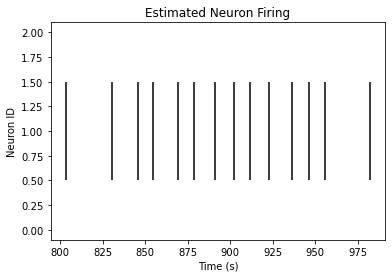

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# Load EEG event data
file_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/sub-4/eeg/sub-4_task-flankersFAR_events.tsv"
df = pd.read_csv(file_path, sep="\t")

# Bandpass filter function
def bandpass_filter(data, lowcut=1, highcut=100, fs=1000, order=4):
    nyq = 0.5 * fs  # Nyquist frequency (500 Hz for fs=1000 Hz)
    low = lowcut / nyq
    high = highcut / nyq
    
    if high >= 1:  # Ensure highcut is below Nyquist
        raise ValueError(f"highcut={highcut} Hz must be < Nyquist frequency ({nyq} Hz)")
    
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Apply bandpass filter to 'value' column
filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)

# Determine dynamic threshold for peak detection
threshold = np.mean(filtered_signal) + np.std(filtered_signal)

# Detect peaks (neuron firing events)
peaks, _ = find_peaks(filtered_signal, height=threshold)
spike_times = df['onset'].iloc[peaks]

# Plot estimated neuron firing times
plt.eventplot(spike_times, colors='black')
plt.xlabel("Time (s)")
plt.ylabel("Neuron ID")
plt.title("Estimated Neuron Firing")
plt.show()


Processing file: /home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/sub-1_task-flankersFAR_events.tsv
Threshold used: 34.65131457585864
Processing file: /home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/sub-2_task-flankersFAR_events.tsv
Threshold used: 34.56017629668826
Processing file: /home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/sub-3_task-flankersFAR_events.tsv
Threshold used: 34.358995693314064
Processing file: /home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/sub-4_task-flankersFAR_events.tsv
Threshold used: 34.750188085913265
Processing file: /home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/sub-5_task-flankersFAR_events.tsv
Threshold used: 34.215462562613205
Processing file: /home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/sub-6_task-flankersFAR_events.tsv
Threshold used: 34.693046590230175
Processing file: /home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/sub-7_task-flankersFAR_events.tsv
Threshold used: 34.72559252793462
Processing file: /home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/sub-8_ta

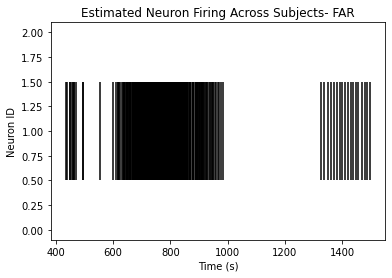

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# Bandpass filter function
def bandpass_filter(data, lowcut=1, highcut=100, fs=1000, order=4):
    nyq = 0.5 * fs  # Nyquist frequency (500 Hz for fs=1000 Hz)
    low = lowcut / nyq
    high = highcut / nyq
    
    if high >= 1:  # Ensure highcut is below Nyquist
        raise ValueError(f"highcut={highcut} Hz must be < Nyquist frequency ({nyq} Hz)")
    
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Function to detect spikes
def detect_spikes(filtered_signal, threshold=None):
    # If no threshold is passed, use mean + std of the signal for threshold
    if threshold is None:
        threshold = filtered_signal.mean() + filtered_signal.std()
        
    print(f"Threshold used: {threshold}")  # Debugging
    peaks, _ = find_peaks(filtered_signal, height=threshold)
    return peaks

# Collect all subjects' spike times
all_subjects_data = []
base_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/"

# Loop through all subjects from sub-1 to sub-25
for subject_id in range(1, 26):  # Adjust range based on available subjects
    file_path = os.path.join(base_path, f"sub-{subject_id}_task-flankersFAR_events.tsv")

    # Ensure the file exists before trying to read it
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t")
        print(f"Processing file: {file_path}")  # Debugging message
        
        # Apply bandpass filter to 'value' column
        filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)

        # Detect spikes with dynamic threshold
        spike_times = detect_spikes(filtered_signal)

        # If no spikes detected, try adjusting threshold manually
        if len(spike_times) == 0:
            print(f"No spikes detected for subject {subject_id}. Trying manual threshold adjustment.")
            spike_times = detect_spikes(filtered_signal, threshold=filtered_signal.mean() + 2 * filtered_signal.std())
        
        # If spikes are detected, add the results to the list
        if len(spike_times) > 0:
            all_subjects_data.append(pd.DataFrame({"Subject": subject_id, "Spike Time": df['onset'].iloc[spike_times]}))
        else:
            print(f"No spikes detected after threshold adjustment for subject {subject_id}.")
    else:
        print(f"Warning: File {file_path} not found.")

# Combine all subject data into a single DataFrame
if all_subjects_data:
    combined_df = pd.concat(all_subjects_data, ignore_index=True)
    print(combined_df.head())
    
    # Optionally, plot all the spike times for visualization
    plt.eventplot(combined_df['Spike Time'], colors='black')
    plt.xlabel("Time (s)")
    plt.ylabel("Neuron ID")
    plt.title("Estimated Neuron Firing Across Subjects- FAR")
    plt.show()
else:
    print("No data to concatenate. Please check if spike detection worked.")


In [27]:
# Calculate total time for each subject (difference between last and first spike time)
combined_df['Spike Time'] = pd.to_numeric(combined_df['Spike Time'])  # Ensure it's numeric

total_time_per_subject = combined_df.groupby('Subject')['Spike Time'].max() - combined_df.groupby('Subject')['Spike Time'].min()

# Calculate mean firing rate per subject (number of spikes / total time)
mean_firing_rate = combined_df.groupby("Subject")["Spike Time"].count() / total_time_per_subject
print("Mean firing rate per subject:\n", mean_firing_rate)


Mean firing rate per subject:
 Subject
1     0.054530
2     0.104138
3     0.104920
4     0.078274
5     0.051170
6     0.096596
7     0.110221
8     0.029257
9     0.046964
10    0.037984
11    0.099692
12    0.057154
13    0.114765
14    0.091701
15    0.040706
16    0.113790
17    0.042346
18    0.104745
19    0.118374
20    0.045311
21    0.051304
22    0.093351
23    0.038219
24    0.035792
25    0.100454
Name: Spike Time, dtype: float64


In [28]:
isi = combined_df.groupby("Subject")["Spike Time"].diff().dropna()
print("Mean ISI:", isi.mean())


Mean ISI: 17.054244791666665


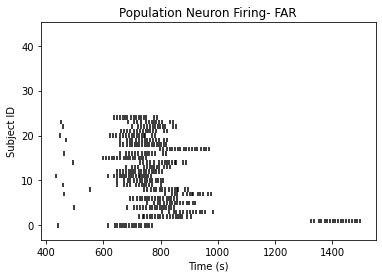

In [10]:
import matplotlib.pyplot as plt

plt.eventplot([combined_df[combined_df["Subject"] == s]["Spike Time"] for s in range(1, 44)], colors='black')
plt.xlabel("Time (s)")
plt.ylabel("Subject ID")
plt.title("Population Neuron Firing- FAR")
plt.show()


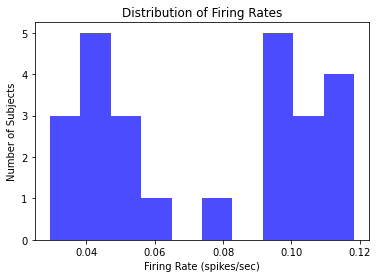

In [31]:
plt.hist(mean_firing_rate, bins=10, color='blue', alpha=0.7)
plt.xlabel("Firing Rate (spikes/sec)")
plt.ylabel("Number of Subjects")
plt.title("Distribution of Firing Rates- FAR")
plt.show()


Processing file: /home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/sub-1_task-FlankerNEAR_events.tsv
Threshold used: 58.99442886590514
Processing file: /home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/sub-2_task-FlankerNEAR_events.tsv
Threshold used: 34.68933367788847
Processing file: /home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/sub-3_task-FlankerNEAR_events.tsv
Threshold used: 34.782668658768344
Processing file: /home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/sub-4_task-FlankerNEAR_events.tsv
Threshold used: 34.74181924343863
Processing file: /home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/sub-5_task-FlankerNEAR_events.tsv
Threshold used: 34.63008353567302
Processing file: /home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/sub-6_task-FlankerNEAR_events.tsv
Threshold used: 34.60203104606821
Processing file: /home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/sub-7_task-FlankerNEAR_events.tsv
Threshold used: 34.28050248900941
Processing file: /home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/sub-8_task-

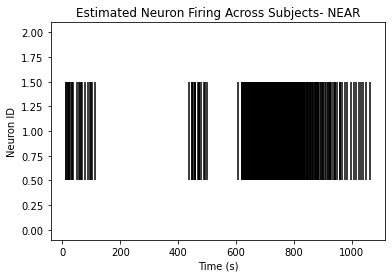

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# Bandpass filter function
def bandpass_filter(data, lowcut=1, highcut=100, fs=1000, order=4):
    nyq = 0.5 * fs  # Nyquist frequency (500 Hz for fs=1000 Hz)
    low = lowcut / nyq
    high = highcut / nyq
    
    if high >= 1:  # Ensure highcut is below Nyquist
        raise ValueError(f"highcut={highcut} Hz must be < Nyquist frequency ({nyq} Hz)")
    
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Function to detect spikes
def detect_spikes(filtered_signal, threshold=None):
    # If no threshold is passed, use mean + std of the signal for threshold
    if threshold is None:
        threshold = filtered_signal.mean() + filtered_signal.std()
        
    print(f"Threshold used: {threshold}")  # Debugging
    peaks, _ = find_peaks(filtered_signal, height=threshold)
    return peaks

# Collect all subjects' spike times
all_subjects_data = []
base_path = "/home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/"

# Loop through all subjects from sub-1 to sub-25
for subject_id in range(1, 26):  # Adjust range based on available subjects
    file_path = os.path.join(base_path, f"sub-{subject_id}_task-FlankerNEAR_events.tsv")

    # Ensure the file exists before trying to read it
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t")
        print(f"Processing file: {file_path}")  # Debugging message
        
        # Apply bandpass filter to 'value' column
        filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)

        # Detect spikes with dynamic threshold
        spike_times = detect_spikes(filtered_signal)

        # If no spikes detected, try adjusting threshold manually
        if len(spike_times) == 0:
            print(f"No spikes detected for subject {subject_id}. Trying manual threshold adjustment.")
            spike_times = detect_spikes(filtered_signal, threshold=filtered_signal.mean() + 2 * filtered_signal.std())
        
        # If spikes are detected, add the results to the list
        if len(spike_times) > 0:
            all_subjects_data.append(pd.DataFrame({"Subject": subject_id, "Spike Time": df['onset'].iloc[spike_times]}))
        else:
            print(f"No spikes detected after threshold adjustment for subject {subject_id}.")
    else:
        print(f"Warning: File {file_path} not found.")

# Combine all subject data into a single DataFrame
if all_subjects_data:
    combined_df = pd.concat(all_subjects_data, ignore_index=True)
    print(combined_df.head())
    
    # Optionally, plot all the spike times for visualization
    plt.eventplot(combined_df['Spike Time'], colors='black')
    plt.xlabel("Time (s)")
    plt.ylabel("Neuron ID")
    plt.title("Estimated Neuron Firing Across Subjects- NEAR")
    plt.savefig('/home/manjeet/Desktop/neuro/result/estimated_NEAR.png', dpi=300, transparent=False, facecolor='white')

    plt.show()
else:
    print("No data to concatenate. Please check if spike detection worked.")


In [24]:
# Calculate total time for each subject (difference between last and first spike time)
combined_df['Spike Time'] = pd.to_numeric(combined_df['Spike Time'])  # Ensure it's numeric

total_time_per_subject = combined_df.groupby('Subject')['Spike Time'].max() - combined_df.groupby('Subject')['Spike Time'].min()

# Calculate mean firing rate per subject (number of spikes / total time)
mean_firing_rate = combined_df.groupby("Subject")["Spike Time"].count() / total_time_per_subject
print("Mean firing rate per subject:\n", mean_firing_rate)


Mean firing rate per subject:
 Subject
1     0.014270
2     0.111053
3     0.053089
4     0.093327
5     0.105222
6     0.043474
7     0.110224
8     0.020298
9     0.056409
10    0.043673
11    0.035408
12    0.036021
13    0.053584
14    0.019948
15    0.039972
16    0.044937
17    0.054337
18    0.039365
19    0.105408
20    0.053714
21    0.056282
22    0.043995
23    0.049321
24    0.038719
25    0.019923
Name: Spike Time, dtype: float64


In [25]:
isi = combined_df.groupby("Subject")["Spike Time"].diff().dropna()
print("Mean ISI:", isi.mean())


Mean ISI: 26.15486597938144


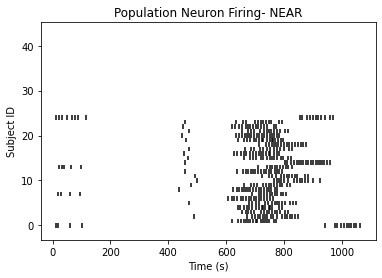

In [19]:
import matplotlib.pyplot as plt

plt.eventplot([combined_df[combined_df["Subject"] == s]["Spike Time"] for s in range(1, 44)], colors='black')
plt.xlabel("Time (s)")
plt.ylabel("Subject ID")
plt.title("Population Neuron Firing- NEAR")
plt.savefig('/home/manjeet/Desktop/neuro/result/Firing_NEAR.png', dpi=300, transparent=False, facecolor='white')

plt.show()


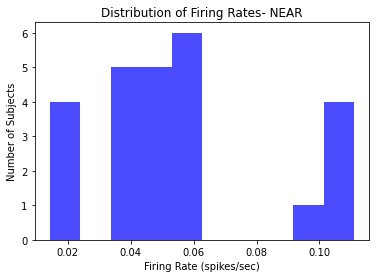

In [26]:
plt.hist(mean_firing_rate, bins=10, color='blue', alpha=0.7)
plt.xlabel("Firing Rate (spikes/sec)")
plt.ylabel("Number of Subjects")
plt.title("Distribution of Firing Rates- NEAR")
plt.savefig('/home/manjeet/Desktop/neuro/result/Histo_NEAR.png', dpi=300, transparent=False, facecolor='white')

plt.show()


In [8]:
import os
import pandas as pd

# Paths for near and far data
near_path = "/home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/"
far_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/"

# Initialize empty lists to hold data
near_all_subjects_data = []
far_all_subjects_data = []

# Function to detect spikes based on the filtered signal (you can customize the spike detection)
def detect_spikes(filtered_signal):
    threshold = np.mean(filtered_signal) + np.std(filtered_signal)
    peaks, _ = find_peaks(filtered_signal, height=threshold)
    return peaks

# Loop through subjects for "near" condition
for subject_id in range(1, 26):  # Assuming subjects are numbered from 1 to 25
    file_path = os.path.join(near_path, f"sub-{subject_id}_task-FlankerNEAR_events.tsv")
    
    # Load the data
    df = pd.read_csv(file_path, sep="\t")
    
    # Apply bandpass filter (You can use the function you defined earlier)
    filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)
    
    # Detect spikes
    spike_times = detect_spikes(filtered_signal)
    
    # Add to the list
    near_all_subjects_data.append(pd.DataFrame({"Subject": subject_id, "Spike Time": df['onset'].iloc[spike_times]}))

# Loop through subjects for "far" condition
for subject_id in range(1, 26):  # Assuming subjects are numbered from 1 to 25
    file_path = os.path.join(far_path, f"sub-{subject_id}_task-flankersFAR_events.tsv")
    
    # Load the data
    df = pd.read_csv(file_path, sep="\t")
    
    # Apply bandpass filter
    filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)
    
    # Detect spikes
    spike_times = detect_spikes(filtered_signal)
    
    # Add to the list
    far_all_subjects_data.append(pd.DataFrame({"Subject": subject_id, "Spike Time": df['onset'].iloc[spike_times]}))

# Combine the data for near and far conditions
near_combined_df = pd.concat(near_all_subjects_data, ignore_index=True)
far_combined_df = pd.concat(far_all_subjects_data, ignore_index=True)

# Combine both near and far data into one DataFrame for analysis
near_combined_df['Condition'] = 'Near'
far_combined_df['Condition'] = 'Far'

combined_df = pd.concat([near_combined_df, far_combined_df], ignore_index=True)



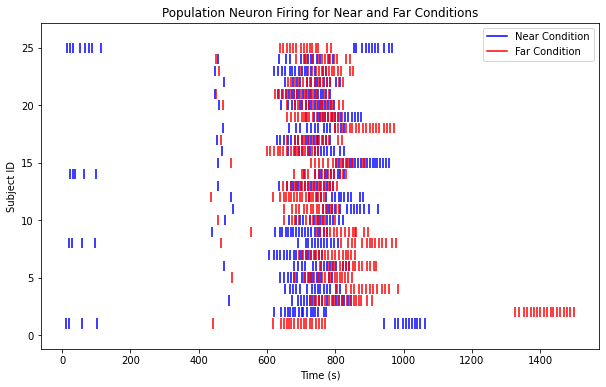

In [11]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(10, 6))

# Separate spike times for near and far conditions
near_spike_times = [combined_df[(combined_df["Condition"] == "Near") & (combined_df["Subject"] == s)]["Spike Time"].values for s in range(1, 26)]
far_spike_times = [combined_df[(combined_df["Condition"] == "Far") & (combined_df["Subject"] == s)]["Spike Time"].values for s in range(1, 26)]

# Plot near condition with one color
plt.eventplot(near_spike_times, colors='blue', lineoffsets=range(1, 26), linelengths=0.9)

# Plot far condition with a different color
plt.eventplot(far_spike_times, colors='red', lineoffsets=range(1, 26), linelengths=0.9)

# **Manually create the legend to avoid duplicates**
plt.plot([], [], color='blue', label='Near Condition')  
plt.plot([], [], color='red', label='Far Condition')

plt.xlabel("Time (s)")
plt.ylabel("Subject ID")
plt.title("Population Neuron Firing for Near and Far Conditions")
plt.legend()  # This now only shows two entries
plt.savefig('/home/manjeet/Desktop/neuro/result/population_neuron_firing.png', dpi=300, transparent=False, facecolor='white')


plt.show()


In [47]:
# Assuming you have the total stimulus time in seconds (you can adjust this value)
total_time_per_subject = 270 * 0.15  # Example: 270 trials, 150 ms per trial (adjust if necessary)

# Calculate mean firing rate for each subject and condition
mean_firing_rate = combined_df.groupby(["Subject", "Condition"])["Spike Time"].count() / total_time_per_subject

# Print mean firing rates
print("Mean Firing Rate per Subject and Condition:\n", mean_firing_rate)


Mean Firing Rate per Subject and Condition:
 Subject  Condition
1        Far          0.444444
         Near         0.370370
2        Far          0.444444
         Near         0.419753
3        Far          0.469136
         Near         0.469136
4        Far          0.345679
         Near         0.370370
5        Far          0.444444
         Near         0.395062
6        Far          0.395062
         Near         0.395062
7        Far          0.444444
         Near         0.419753
8        Far          0.370370
         Near         0.395062
9        Far          0.395062
         Near         0.469136
10       Far          0.320988
         Near         0.370370
11       Far          0.395062
         Near         0.370370
12       Far          0.469136
         Near         0.345679
13       Far          0.444444
         Near         0.444444
14       Far          0.345679
         Near         0.395062
15       Far          0.395062
         Near         0.493827
16    

In [48]:
from scipy import stats

# Get firing rates for both conditions
near_firing_rates = mean_firing_rate[mean_firing_rate.index.get_level_values('Condition') == "Near"]
far_firing_rates = mean_firing_rate[mean_firing_rate.index.get_level_values('Condition') == "Far"]

# Perform a paired t-test to compare the firing rates between near and far conditions
t_stat, p_value = stats.ttest_rel(near_firing_rates, far_firing_rates)

print(f"T-statistic: {t_stat}, P-value: {p_value}")


T-statistic: 0.3419511258536729, P-value: 0.7353639497116419


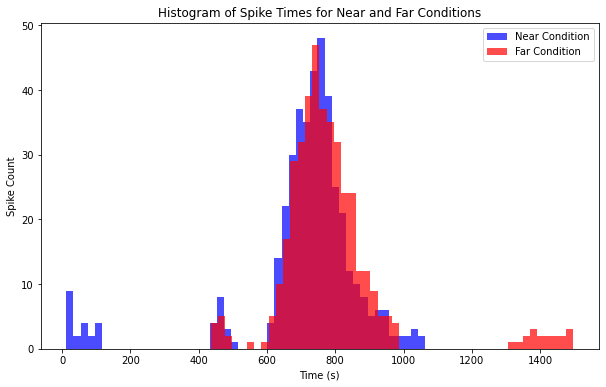

In [12]:
import matplotlib.pyplot as plt

# Plot histogram of spike times for each condition
plt.figure(figsize=(10, 6))

# Plot histogram for the 'near' condition
plt.hist([time for times in near_spike_times for time in times], bins=50, color='blue', alpha=0.7, label='Near Condition')

# Plot histogram for the 'far' condition
plt.hist([time for times in far_spike_times for time in times], bins=50, color='red', alpha=0.7, label='Far Condition')

plt.xlabel("Time (s)")
plt.ylabel("Spike Count")
plt.title("Histogram of Spike Times for Near and Far Conditions")
plt.legend()
plt.savefig('/home/manjeet/Desktop/neuro/result/mer_Histogram.png', dpi=300, transparent=False, facecolor='white')

plt.show()


/tmp/ipykernel_10668/3312667041.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Spike Time', data=combined_df, palette="Set2")


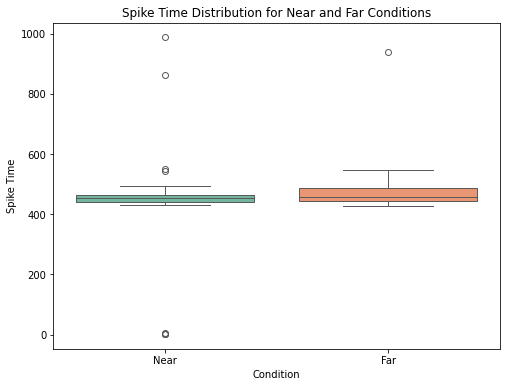

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

# Paths for near and far data
near_path = "/home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/"
far_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/"

# Initialize empty lists to hold data
near_all_subjects_data = []
far_all_subjects_data = []

# Function to detect spikes based on the filtered signal (you can customize the spike detection)
def detect_spikes(filtered_signal):
    threshold = np.mean(filtered_signal) + np.std(filtered_signal)
    peaks, _ = find_peaks(filtered_signal, height=threshold)
    return peaks

# Assuming the bandpass filter is defined, if not, replace with actual filter code
def bandpass_filter(signal, lowcut, highcut, fs):
    # This is a placeholder function, replace with the actual bandpass filter implementation
    return signal  # For now, just return the original signal

# Loop through subjects for "near" condition
for subject_id in range(1, 26):  # Assuming subjects are numbered from 1 to 25
    file_path = os.path.join(near_path, f"sub-{subject_id}_task-FlankerNEAR_events.tsv")
    
    # Load the data
    df = pd.read_csv(file_path, sep="\t")
    
    # Apply bandpass filter
    filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)
    
    # Detect spikes
    spike_times = detect_spikes(filtered_signal)
    
    # Add to the list
    near_all_subjects_data.append(pd.DataFrame({"Subject": subject_id, "Spike Time": df['onset'].iloc[spike_times]}))

# Loop through subjects for "far" condition
for subject_id in range(1, 26):  # Assuming subjects are numbered from 1 to 25
    file_path = os.path.join(far_path, f"sub-{subject_id}_task-flankersFAR_events.tsv")
    
    # Load the data
    df = pd.read_csv(file_path, sep="\t")
    
    # Apply bandpass filter
    filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)
    
    # Detect spikes
    spike_times = detect_spikes(filtered_signal)
    
    # Add to the list
    far_all_subjects_data.append(pd.DataFrame({"Subject": subject_id, "Spike Time": df['onset'].iloc[spike_times]}))

# Combine the data for near and far conditions
near_combined_df = pd.concat(near_all_subjects_data, ignore_index=True)
far_combined_df = pd.concat(far_all_subjects_data, ignore_index=True)

# Combine both near and far data into one DataFrame for analysis
near_combined_df['Condition'] = 'Near'
far_combined_df['Condition'] = 'Far'

combined_df = pd.concat([near_combined_df, far_combined_df], ignore_index=True)

# Create a boxplot for the spike times for near and far conditions
plt.figure(figsize=(8, 6))
sns.boxplot(x='Condition', y='Spike Time', data=combined_df, palette="Set2")
plt.title('Spike Time Distribution for Near and Far Conditions')
plt.xlabel('Condition')
plt.ylabel('Spike Time')
plt.savefig('/home/manjeet/Desktop/neuro/result/boxplot.png', dpi=300, transparent=False, facecolor='white')

plt.show()


/tmp/ipykernel_5240/1485221193.py:20: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  cwt_matrix = cwt(spike_times, wavelet=morlet, widths=widths)


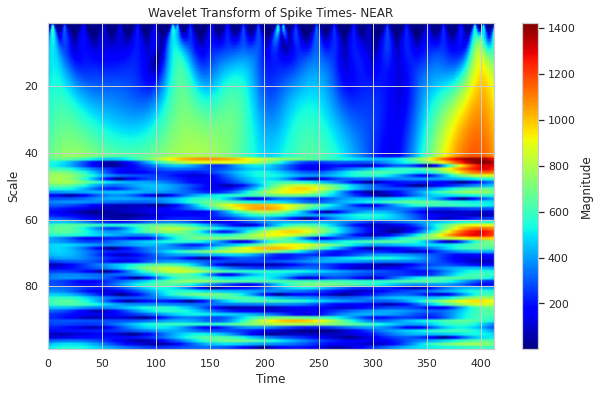

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy.signal import cwt, morlet

# Load spike data from TSV file
file_path = "/home/manjeet/Desktop/neuro/all_subjects_spikes_NEAR.tsv"
df = pd.read_csv(file_path, sep="\t")

# Extract spike times
spike_times = df["Spike Time"].values

# Define parameters for wavelet transform
fs = 1000  # Sampling frequency (adjust if needed)
t = np.arange(0, len(spike_times))  # Time indices
widths = np.arange(1, 100)  # Scale range for wavelet transform

# Apply Continuous Wavelet Transform (CWT)
cwt_matrix = cwt(spike_times, wavelet=morlet, widths=widths)

# Plot Scalogram (Time-Frequency Representation)
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(cwt_matrix), aspect='auto', extent=[t.min(), t.max(), widths.max(), widths.min()], cmap='jet')
plt.colorbar(label="Magnitude")
plt.xlabel("Time")
plt.ylabel("Scale")
plt.title("Wavelet Transform of Spike Times- NEAR")
plt.show()


/tmp/ipykernel_5240/4037335548.py:20: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  cwt_matrix = cwt(spike_times, wavelet=morlet, widths=widths)


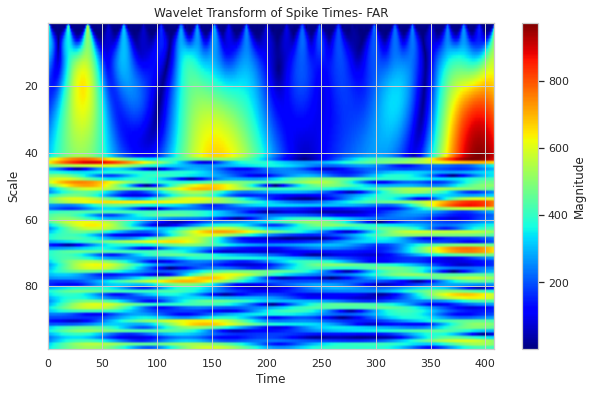

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy.signal import cwt, morlet

# Load spike data from TSV file
file_path = "/home/manjeet/Desktop/neuro/all_subjects_spikes_FAR.tsv"
df = pd.read_csv(file_path, sep="\t")

# Extract spike times
spike_times = df["Spike Time"].values

# Define parameters for wavelet transform
fs = 1000  # Sampling frequency (adjust if needed)
t = np.arange(0, len(spike_times))  # Time indices
widths = np.arange(1, 100)  # Scale range for wavelet transform

# Apply Continuous Wavelet Transform (CWT)
cwt_matrix = cwt(spike_times, wavelet=morlet, widths=widths)

# Plot Scalogram (Time-Frequency Representation)
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(cwt_matrix), aspect='auto', extent=[t.min(), t.max(), widths.max(), widths.min()], cmap='jet')
plt.colorbar(label="Magnitude")
plt.xlabel("Time")
plt.ylabel("Scale")
plt.title("Wavelet Transform of Spike Times- FAR")
plt.show()


/tmp/ipykernel_5240/2764443158.py:27: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='jet')  # Convert to dB scale


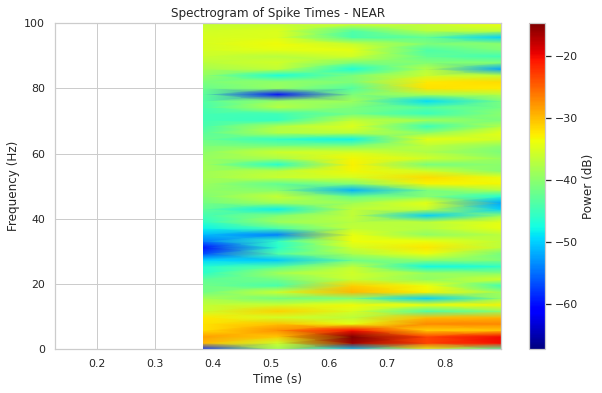

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Load spike data from TSV file
file_path = "/home/manjeet/Desktop/neuro/all_subjects_spikes_NEAR.tsv"
df = pd.read_csv(file_path, sep="\t")

# Extract spike times
spike_times = df["Spike Time"].values

# Define parameters
fs = 1000  # Sampling frequency (adjust based on your data)
duration = int(spike_times.max()) + 1  # Total time (in ms), ensuring full range
signal = np.zeros(duration)  # Initialize signal

# Convert spike times into a binary signal (spike=1, no spike=0)
spike_indices = spike_times.astype(int)
signal[spike_indices] = 1  # Mark spike occurrences

# Compute Spectrogram using Short-Time Fourier Transform (STFT)
f, t, Sxx = spectrogram(signal, fs=fs, nperseg=256, noverlap=128, nfft=512)

# Plot Spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='jet')  # Convert to dB scale
plt.colorbar(label="Power (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of Spike Times - NEAR")
plt.ylim(0, 100)  # Adjust based on frequency range of interest
plt.show()


/tmp/ipykernel_5240/3325811926.py:27: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='jet')  # Convert to dB scale


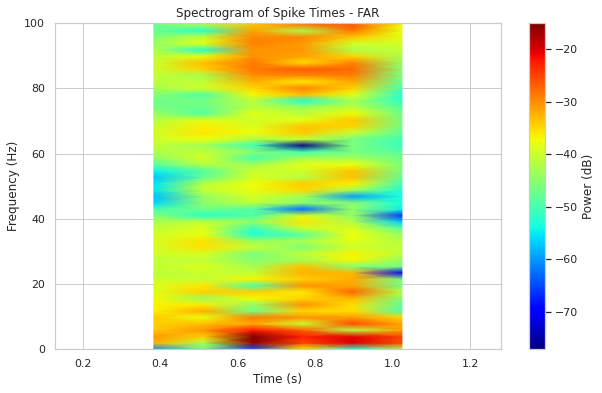

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Load spike data from TSV file
file_path = "/home/manjeet/Desktop/neuro/all_subjects_spikes_FAR.tsv"
df = pd.read_csv(file_path, sep="\t")

# Extract spike times
spike_times = df["Spike Time"].values

# Define parameters
fs = 1000  # Sampling frequency (adjust based on your data)
duration = int(spike_times.max()) + 1  # Total time (in ms), ensuring full range
signal = np.zeros(duration)  # Initialize signal

# Convert spike times into a binary signal (spike=1, no spike=0)
spike_indices = spike_times.astype(int)
signal[spike_indices] = 1  # Mark spike occurrences

# Compute Spectrogram using Short-Time Fourier Transform (STFT)
f, t, Sxx = spectrogram(signal, fs=fs, nperseg=256, noverlap=128, nfft=512)

# Plot Spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='jet')  # Convert to dB scale
plt.colorbar(label="Power (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of Spike Times - FAR")
plt.ylim(0, 100)  # Adjust based on frequency range of interest
plt.show()


Processing FAR condition...


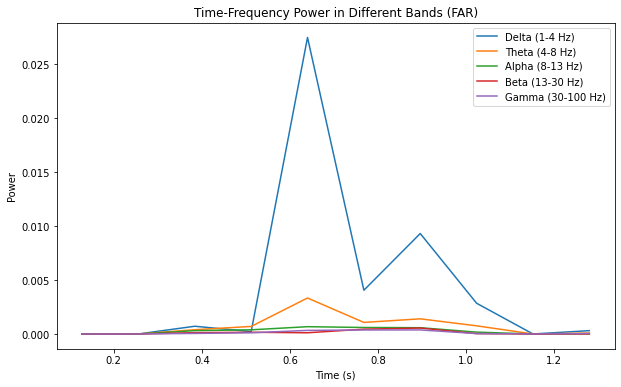

Processing NEAR condition...


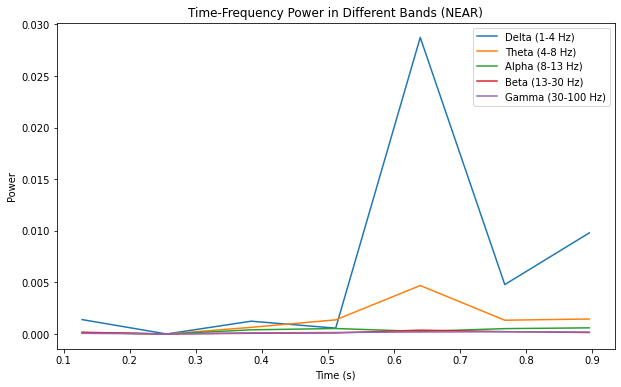

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Function to load and process spike data
def load_spike_data(file_path, fs=1000):
    df = pd.read_csv(file_path, sep="\t")
    spike_times = df["Spike Time"].values.astype(int)
    
    # Create binary spike signal
    duration = spike_times.max() + 1 if len(spike_times) > 0 else 1
    signal = np.zeros(duration)
    signal[spike_times] = 1  # Mark spike occurrences
    return signal, fs

# Function to compute spectrogram
def compute_spectrogram(signal, fs):
    f, t, Sxx = spectrogram(signal, fs=fs, nperseg=256, noverlap=128, nfft=512)
    return f, t, Sxx

# Function to extract power in frequency bands
def extract_band_power(f, Sxx):
    bands = {
        "Delta (1-4 Hz)": (1, 4),
        "Theta (4-8 Hz)": (4, 8),
        "Alpha (8-13 Hz)": (8, 13),
        "Beta (13-30 Hz)": (13, 30),
        "Gamma (30-100 Hz)": (30, 100)
    }
    
    power_bands = {}
    for band, (low, high) in bands.items():
        band_indices = np.where((f >= low) & (f <= high))[0]
        power_bands[band] = np.mean(Sxx[band_indices, :], axis=0)
    
    return power_bands

# Paths for FAR and NEAR conditions
paths = {
    "FAR": "/home/manjeet/Desktop/neuro/all_subjects_spikes_FAR.tsv",
    "NEAR": "/home/manjeet/Desktop/neuro/all_subjects_spikes_NEAR.tsv"
}

# Process and visualize power in different bands
for condition, file_path in paths.items():
    print(f"Processing {condition} condition...")
    
    # Load spike data
    signal, fs = load_spike_data(file_path, fs=1000)

    # Compute spectrogram
    f, t, Sxx = compute_spectrogram(signal, fs)

    # Extract power in different bands
    power_bands = extract_band_power(f, Sxx)

    # Plot power in different frequency bands
    plt.figure(figsize=(10, 6))
    for band, power in power_bands.items():
        plt.plot(t, power, label=band)
    
    plt.xlabel("Time (s)")
    plt.ylabel("Power")
    plt.title(f"Time-Frequency Power in Different Bands ({condition})")
    plt.legend()
    plt.savefig('/home/manjeet/Desktop/neuro/result/Time_FAR.png', dpi=300, transparent=False, facecolor='white')

    plt.show()


Correlation between NEAR and FAR spiking activity: 0.4283 (p=6.9851e-68)


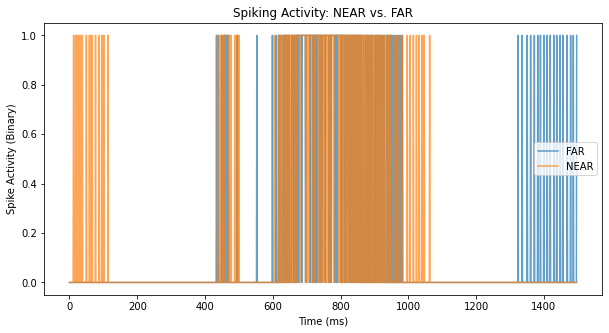

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Function to load and process spike data into binary time-series
def load_spike_signal(file_path, duration=None, fs=1000):
    df = pd.read_csv(file_path, sep="\t")
    spike_times = df["Spike Time"].values.astype(int)

    if duration is None:
        duration = spike_times.max() + 1 if len(spike_times) > 0 else 1

    signal = np.zeros(duration)
    signal[spike_times] = 1  # Mark spike occurrences
    return signal

# File paths
file_path_far = "/home/manjeet/Desktop/neuro/all_subjects_spikes_FAR.tsv"
file_path_near = "/home/manjeet/Desktop/neuro/all_subjects_spikes_NEAR.tsv"

# Load spike signals
signal_far = load_spike_signal(file_path_far)
signal_near = load_spike_signal(file_path_near, duration=len(signal_far))  # Align duration

# Compute correlation
correlation, p_value = pearsonr(signal_far, signal_near)
print(f"Correlation between NEAR and FAR spiking activity: {correlation:.4f} (p={p_value:.4e})")

# Plot signals over time
plt.figure(figsize=(10, 5))
plt.plot(signal_far, label="FAR", alpha=0.7)
plt.plot(signal_near, label="NEAR", alpha=0.7)
plt.xlabel("Time (ms)")
plt.ylabel("Spike Activity (Binary)")
plt.title("Spiking Activity: NEAR vs. FAR")
plt.legend()
plt.savefig('/home/manjeet/Desktop/neuro/result/spike_Activity.png', dpi=300, transparent=False, facecolor='white')

plt.show()



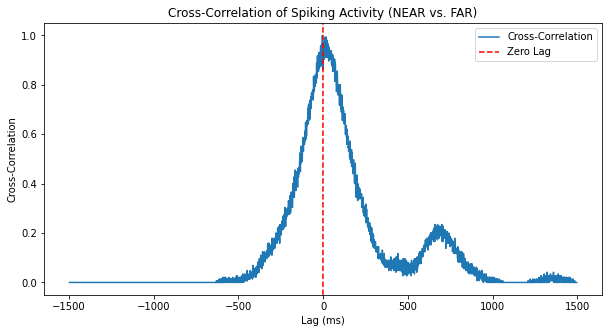

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Function to load and process spike data into binary time-series
def load_spike_signal(file_path, duration=None):
    df = pd.read_csv(file_path, sep="\t")
    spike_times = df["Spike Time"].values.astype(int)

    if duration is None:
        duration = spike_times.max() + 1 if len(spike_times) > 0 else 1

    signal = np.zeros(duration)
    signal[spike_times] = 1  # Mark spike occurrences
    return signal

# File paths
file_path_far = "/home/manjeet/Desktop/neuro/all_subjects_spikes_FAR.tsv"
file_path_near = "/home/manjeet/Desktop/neuro/all_subjects_spikes_NEAR.tsv"

# Load spike signals and align their durations
signal_far = load_spike_signal(file_path_far)
signal_near = load_spike_signal(file_path_near, duration=len(signal_far))  # Ensure same length

# Compute cross-correlation
lags = np.arange(-len(signal_far) + 1, len(signal_far))  # Lag values
cross_corr = np.correlate(signal_far, signal_near, mode="full")

# Normalize cross-correlation
cross_corr = cross_corr / np.max(cross_corr)  # Normalize to max value

# Plot cross-correlation function
plt.figure(figsize=(10, 5))
plt.plot(lags, cross_corr, label="Cross-Correlation")
plt.axvline(0, color="r", linestyle="--", label="Zero Lag")
plt.xlabel("Lag (ms)")
plt.ylabel("Cross-Correlation")
plt.title("Cross-Correlation of Spiking Activity (NEAR vs. FAR)")
plt.legend()
plt.savefig('/home/manjeet/Desktop/neuro/result/crosscor.png', dpi=300, transparent=False, facecolor='white')

plt.show()


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load spike data and convert to binary signal
def load_spike_signal(file_path, duration=None):
    df = pd.read_csv(file_path, sep="\t")
    spike_times = df["Spike Time"].values.astype(int)

    if duration is None:
        duration = spike_times.max() + 1 if len(spike_times) > 0 else 1

    signal = np.zeros(duration)
    signal[spike_times] = 1  # Mark spike occurrences
    return signal

# File paths
file_path_far = "/home/manjeet/Desktop/neuro/all_subjects_spikes_FAR.tsv"
file_path_near = "/home/manjeet/Desktop/neuro/all_subjects_spikes_NEAR.tsv"

# Load spike signals and align their durations
signal_far = load_spike_signal(file_path_far)
signal_near = load_spike_signal(file_path_near, duration=len(signal_far))

# Descriptive statistics for FAR and NEAR
stats_far = {
    "Mean": np.mean(signal_far),
    "Median": np.median(signal_far),
    "Min": np.min(signal_far),
    "Max": np.max(signal_far),
    "Std Dev": np.std(signal_far)
}

stats_near = {
    "Mean": np.mean(signal_near),
    "Median": np.median(signal_near),
    "Min": np.min(signal_near),
    "Max": np.max(signal_near),
    "Std Dev": np.std(signal_near)
}

# Print descriptive statistics
print("FAR Condition Statistics:")
for key, value in stats_far.items():
    print(f"{key}: {value:.4f}")

print("\nNEAR Condition Statistics:")
for key, value in stats_near.items():
    print(f"{key}: {value:.4f}")




FAR Condition Statistics:
Mean: 0.1622
Median: 0.0000
Min: 0.0000
Max: 1.0000
Std Dev: 0.3686

NEAR Condition Statistics:
Mean: 0.1609
Median: 0.0000
Min: 0.0000
Max: 1.0000
Std Dev: 0.3674


/tmp/ipykernel_5240/3229491267.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Condition', y='Spike Time', data=combined_df, palette="muted", inner=None, alpha=0.6)  # KDE distribution


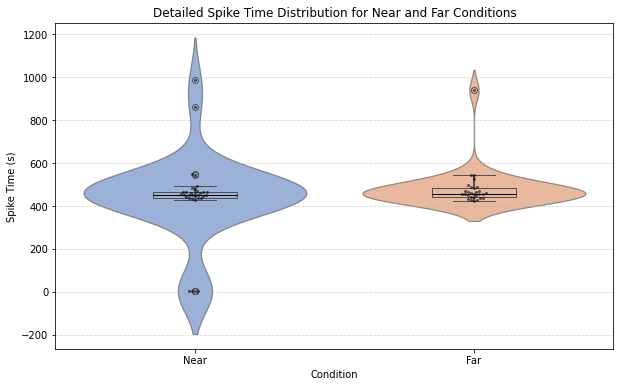

In [31]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

# Paths for near and far data
near_path = "/home/manjeet/Desktop/neuro/ds005866-1.0.1/eeg/"
far_path = "/home/manjeet/Desktop/neuro/ds005868-1.0.1/eeg/"

# Initialize empty lists to hold data
near_all_subjects_data = []
far_all_subjects_data = []

# Function to detect spikes based on the filtered signal
def detect_spikes(filtered_signal):
    threshold = np.mean(filtered_signal) + np.std(filtered_signal)
    peaks, _ = find_peaks(filtered_signal, height=threshold)
    return peaks

# Placeholder for bandpass filter (replace with actual implementation)
def bandpass_filter(signal, lowcut, highcut, fs):
    return signal  # No actual filtering for now

# Load data and process "near" condition
for subject_id in range(1, 26):  
    file_path = os.path.join(near_path, f"sub-{subject_id}_task-FlankerNEAR_events.tsv")
    df = pd.read_csv(file_path, sep="\t")
    filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)
    spike_times = detect_spikes(filtered_signal)
    near_all_subjects_data.append(pd.DataFrame({"Subject": subject_id, "Spike Time": df['onset'].iloc[spike_times]}))

# Load data and process "far" condition
for subject_id in range(1, 26):  
    file_path = os.path.join(far_path, f"sub-{subject_id}_task-flankersFAR_events.tsv")
    df = pd.read_csv(file_path, sep="\t")
    filtered_signal = bandpass_filter(df['value'].values, lowcut=1, highcut=100, fs=1000)
    spike_times = detect_spikes(filtered_signal)
    far_all_subjects_data.append(pd.DataFrame({"Subject": subject_id, "Spike Time": df['onset'].iloc[spike_times]}))

# Combine DataFrames
near_combined_df = pd.concat(near_all_subjects_data, ignore_index=True)
far_combined_df = pd.concat(far_all_subjects_data, ignore_index=True)

near_combined_df['Condition'] = 'Near'
far_combined_df['Condition'] = 'Far'
combined_df = pd.concat([near_combined_df, far_combined_df], ignore_index=True)

# **Enhanced Plot: Boxplot + Violinplot + Swarmplot**
plt.figure(figsize=(10, 6))
sns.violinplot(x='Condition', y='Spike Time', data=combined_df, palette="muted", inner=None, alpha=0.6)  # KDE distribution
sns.boxplot(x='Condition', y='Spike Time', data=combined_df, width=0.3, showcaps=True, boxprops={'facecolor':'None'}, whiskerprops={'linewidth':2}, medianprops={'color':'black'})  # Boxplot with clear style
sns.swarmplot(x='Condition', y='Spike Time', data=combined_df, color='black', alpha=0.6, size=3)  # Individual points

# Add titles and labels
plt.title('Detailed Spike Time Distribution for Near and Far Conditions')
plt.xlabel('Condition')
plt.ylabel('Spike Time (s)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show plot
plt.show()
